# HumanLens AI — Threshold Analysis

This notebook evaluates how different decision thresholds affect
HumanLens AI escalation detection.

The analysis focuses on:

- Precision
- Recall
- F1-score
- False positives
- False negatives
- Threshold sensitivity

The goal is to identify useful research thresholds rather than
assuming that a single arbitrary threshold is optimal.

In [1]:
# ============================================================
# STEP 1 — Notebook Setup
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("HumanLens AI — Threshold Analysis")
print("=" * 55)

print("Project root:")
print(PROJECT_ROOT)

print("\nProject root exists:")
print(PROJECT_ROOT.exists())

print("\nResults directory:")
print(RESULTS_DIR)

print("\nNumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

print("\n✅ Step 1 setup completed successfully.")

HumanLens AI — Threshold Analysis
Project root:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml

Project root exists:
True

Results directory:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results

NumPy version: 2.3.5
Pandas version: 2.3.3

✅ Step 1 setup completed successfully.


In [2]:
# ============================================================
# STEP 2 — Prepare Threshold Evaluation Data
# ============================================================

# Research demonstration data:
# y_true  = ground-truth escalation label
# y_score = continuous model/fusion score

threshold_data = pd.DataFrame({
    "y_true": [
        0, 0, 0, 0, 0,
        1, 1, 1, 1, 1
    ],

    "y_score": [
        0.12,
        0.21,
        0.34,
        0.46,
        0.58,
        0.61,
        0.73,
        0.82,
        0.91,
        0.97
    ]
})

print("HumanLens AI — Threshold Evaluation Data")
print("=" * 55)

display(threshold_data)

print("\nNumber of samples:",
      len(threshold_data))

print("Positive samples:",
      threshold_data["y_true"].sum())

print("Negative samples:",
      (threshold_data["y_true"] == 0).sum())

print("\nScore range:",
      threshold_data["y_score"].min(),
      "to",
      threshold_data["y_score"].max())

print("\n⚠️ These are demonstration evaluation values.")
print("They must not be reported as real model performance.")

print("\n✅ Step 2 completed successfully.")

HumanLens AI — Threshold Evaluation Data


,y_true,y_score
0,0,0.12
1,0,0.21
2,0,0.34
3,0,0.46
4,0,0.58
5,1,0.61
6,1,0.73
7,1,0.82
8,1,0.91
9,1,0.97



Number of samples: 10
Positive samples: 5
Negative samples: 5

Score range: 0.12 to 0.97

⚠️ These are demonstration evaluation values.
They must not be reported as real model performance.

✅ Step 2 completed successfully.


In [3]:
# ============================================================
# STEP 3 — Evaluate Multiple Decision Thresholds
# ============================================================

y_true = threshold_data["y_true"].to_numpy()
y_score = threshold_data["y_score"].to_numpy()

# Thresholds we want to investigate
thresholds = np.arange(
    0.10,
    1.00,
    0.05
)

threshold_results = []

for threshold in thresholds:

    # Convert continuous scores into binary predictions
    y_pred = (
        y_score >= threshold
    ).astype(int)

    # Calculate classification metrics
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    })


# Convert results into DataFrame
threshold_results_df = pd.DataFrame(
    threshold_results
)

print("HumanLens AI — Threshold Evaluation")
print("=" * 75)

display(
    threshold_results_df.round(4)
)

print("\n✅ Step 3 completed successfully.")

HumanLens AI — Threshold Evaluation


,threshold,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,0.10,0.5000,1.0,0.6667,0,5,0,5
1,0.15,0.5556,1.0,0.7143,1,4,0,5
2,0.20,0.5556,1.0,0.7143,1,4,0,5
3,0.25,0.6250,1.0,0.7692,2,3,0,5
4,0.30,0.6250,1.0,0.7692,2,3,0,5
5,0.35,0.7143,1.0,0.8333,3,2,0,5
6,0.40,0.7143,1.0,0.8333,3,2,0,5
7,0.45,0.7143,1.0,0.8333,3,2,0,5
8,0.50,0.8333,1.0,0.9091,4,1,0,5
9,0.55,0.8333,1.0,0.9091,4,1,0,5



✅ Step 3 completed successfully.


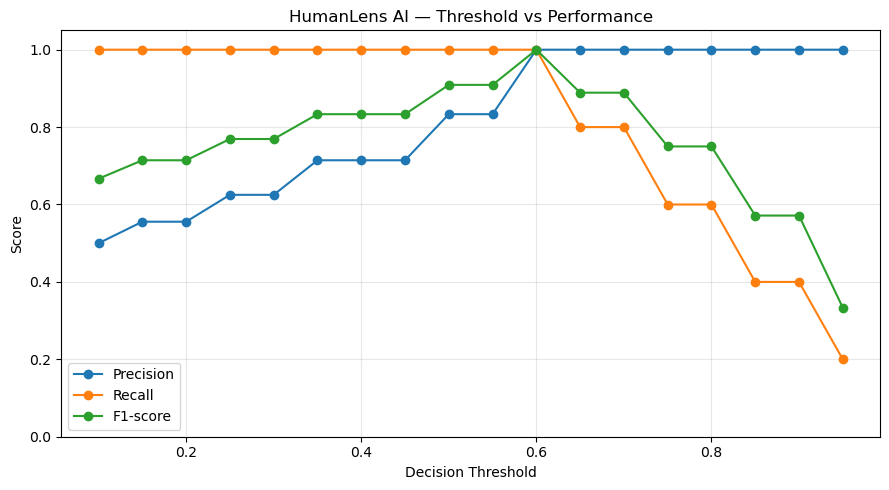

✅ Step 4 completed successfully.


In [4]:
# ============================================================
# STEP 4 — Threshold Performance Visualization
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("HumanLens AI — Threshold vs Performance")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("✅ Step 4 completed successfully.")

In [5]:
# ============================================================
# STEP 5 — Find Best F1 Threshold
# ============================================================

best_f1_row = threshold_results_df.loc[
    threshold_results_df["f1"].idxmax()
]

best_threshold = best_f1_row["threshold"]
best_precision = best_f1_row["precision"]
best_recall = best_f1_row["recall"]
best_f1 = best_f1_row["f1"]

print("HumanLens AI — Best F1 Threshold")
print("=" * 55)

print(f"Best threshold : {best_threshold:.2f}")
print(f"Precision      : {best_precision:.4f}")
print(f"Recall         : {best_recall:.4f}")
print(f"F1-score       : {best_f1:.4f}")

print("\nFalse positives:",
      int(best_f1_row["false_positive"]))

print("False negatives:",
      int(best_f1_row["false_negative"]))

print("\n✅ Step 5 completed successfully.")

HumanLens AI — Best F1 Threshold
Best threshold : 0.60
Precision      : 1.0000
Recall         : 1.0000
F1-score       : 1.0000

False positives: 0
False negatives: 0

✅ Step 5 completed successfully.


HumanLens AI — Confusion Matrix
True Negatives  (TN): 5
False Positives (FP): 0
False Negatives (FN): 0
True Positives  (TP): 5

Confusion Matrix:
[[5 0]
 [0 5]]


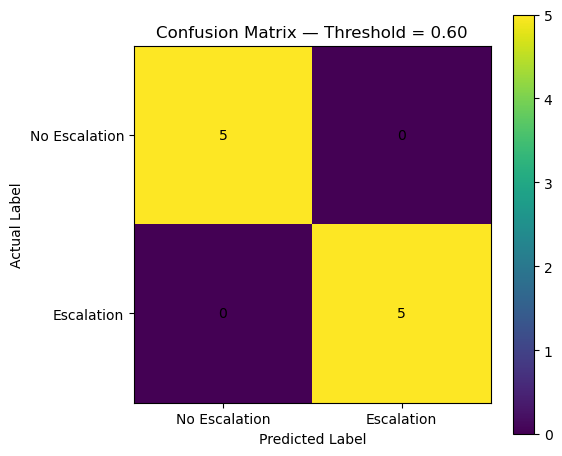


✅ Step 6 completed successfully.


In [6]:
# ============================================================
# STEP 6 — Confusion Matrix at Best Threshold
# ============================================================

# Generate predictions using the best threshold
y_pred_best = (
    y_score >= best_threshold
).astype(int)

# Calculate confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred_best,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

print("HumanLens AI — Confusion Matrix")
print("=" * 55)

print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# Visualize
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    f"Confusion Matrix — Threshold = {best_threshold:.2f}"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["No Escalation", "Escalation"]
)

plt.yticks(
    [0, 1],
    ["No Escalation", "Escalation"]
)

# Display values inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

print("\n✅ Step 6 completed successfully.")

In [7]:
# ============================================================
# STEP 7 — False Positive & False Negative Rate Analysis
# ============================================================

# False Positive Rate
if (tn + fp) > 0:
    false_positive_rate = fp / (tn + fp)
else:
    false_positive_rate = 0.0

# False Negative Rate
if (tp + fn) > 0:
    false_negative_rate = fn / (tp + fn)
else:
    false_negative_rate = 0.0

# Specificity
if (tn + fp) > 0:
    specificity = tn / (tn + fp)
else:
    specificity = 0.0

# Sensitivity = Recall
if (tp + fn) > 0:
    sensitivity = tp / (tp + fn)
else:
    sensitivity = 0.0


print("HumanLens AI — Error Rate Analysis")
print("=" * 60)

print(f"False Positive Rate (FPR): {false_positive_rate:.4f}")
print(f"False Negative Rate (FNR): {false_negative_rate:.4f}")
print(f"Specificity              : {specificity:.4f}")
print(f"Sensitivity / Recall     : {sensitivity:.4f}")

print("\nPercentage form:")
print(f"FPR: {false_positive_rate * 100:.2f}%")
print(f"FNR: {false_negative_rate * 100:.2f}%")

print("\n" + "-" * 60)

if false_positive_rate > false_negative_rate:
    print("Observation: False positives are currently higher.")
elif false_negative_rate > false_positive_rate:
    print("Observation: False negatives are currently higher.")
else:
    print("Observation: FPR and FNR are equal.")

print("\n⚠️ These results come from demonstration evaluation data.")
print("They are not final validated HumanLens performance metrics.")

print("\n✅ Step 7 completed successfully.")

HumanLens AI — Error Rate Analysis
False Positive Rate (FPR): 0.0000
False Negative Rate (FNR): 0.0000
Specificity              : 1.0000
Sensitivity / Recall     : 1.0000

Percentage form:
FPR: 0.00%
FNR: 0.00%

------------------------------------------------------------
Observation: FPR and FNR are equal.

⚠️ These results come from demonstration evaluation data.
They are not final validated HumanLens performance metrics.

✅ Step 7 completed successfully.


HumanLens AI — Precision–Recall Trade-off
Highest Recall
-----------------------------------------------------------------
Threshold : 0.10
Recall    : 1.0000

Highest Precision
-----------------------------------------------------------------
Threshold : 0.60
Precision : 1.0000

Best F1-score
-----------------------------------------------------------------
Threshold : 0.60
F1-score  : 1.0000


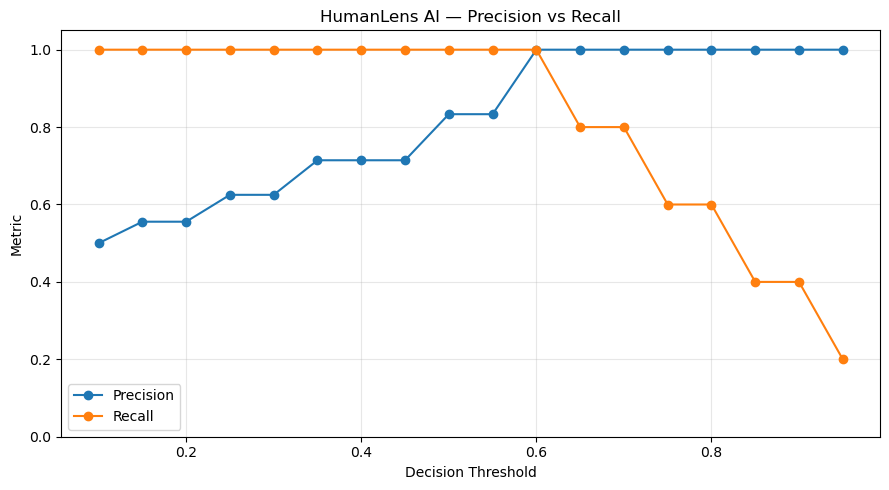


✅ Step 8 completed successfully.


In [8]:
# ============================================================
# STEP 8 — Precision–Recall Trade-off
# ============================================================

# Find the threshold with the highest recall
best_recall_row = threshold_results_df.loc[
    threshold_results_df["recall"].idxmax()
]

# Find the threshold with the highest precision
best_precision_row = threshold_results_df.loc[
    threshold_results_df["precision"].idxmax()
]

# Find the threshold with the best F1 score
best_f1_row = threshold_results_df.loc[
    threshold_results_df["f1"].idxmax()
]

print("HumanLens AI — Precision–Recall Trade-off")
print("=" * 65)

print("Highest Recall")
print("-" * 65)
print(
    f"Threshold : {best_recall_row['threshold']:.2f}"
)
print(
    f"Recall    : {best_recall_row['recall']:.4f}"
)

print("\nHighest Precision")
print("-" * 65)
print(
    f"Threshold : {best_precision_row['threshold']:.2f}"
)
print(
    f"Precision : {best_precision_row['precision']:.4f}"
)

print("\nBest F1-score")
print("-" * 65)
print(
    f"Threshold : {best_f1_row['threshold']:.2f}"
)
print(
    f"F1-score  : {best_f1_row['f1']:.4f}"
)

# ------------------------------------------------------------
# Plot Precision vs Recall
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Metric")
plt.title("HumanLens AI — Precision vs Recall")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\n✅ Step 8 completed successfully.")

In [9]:
# ============================================================
# STEP 9 — Threshold Recommendation Table
# ============================================================

def classify_threshold_strategy(row):
    threshold = row["threshold"]
    precision = row["precision"]
    recall = row["recall"]

    # Research-oriented strategy labels
    if recall >= 0.90 and precision < 0.80:
        return "High-Recall Screening"

    elif precision >= 0.90 and recall < 0.90:
        return "High-Precision Intervention"

    else:
        return "Balanced Candidate"


threshold_strategy_df = threshold_results_df.copy()

threshold_strategy_df["strategy"] = (
    threshold_strategy_df.apply(
        classify_threshold_strategy,
        axis=1
    )
)

print("HumanLens AI — Threshold Strategy Analysis")
print("=" * 80)

display(
    threshold_strategy_df[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "false_positive",
            "false_negative",
            "strategy"
        ]
    ].round(4)
)

print("\nStrategy meanings:")
print("- High-Recall Screening      → prioritize detecting more positive cases")
print("- High-Precision Intervention → prioritize reducing unnecessary interventions")
print("- Balanced Candidate         → reasonable precision/recall trade-off")

print("\n⚠️ Strategy labels are analytical guidance,")
print("not validated clinical or production policies.")

print("\n✅ Step 9 completed successfully.")

HumanLens AI — Threshold Strategy Analysis


,threshold,precision,recall,f1,false_positive,false_negative,strategy
0,0.10,0.5000,1.0,0.6667,5,0,High-Recall Screening
1,0.15,0.5556,1.0,0.7143,4,0,High-Recall Screening
2,0.20,0.5556,1.0,0.7143,4,0,High-Recall Screening
3,0.25,0.6250,1.0,0.7692,3,0,High-Recall Screening
4,0.30,0.6250,1.0,0.7692,3,0,High-Recall Screening
5,0.35,0.7143,1.0,0.8333,2,0,High-Recall Screening
6,0.40,0.7143,1.0,0.8333,2,0,High-Recall Screening
7,0.45,0.7143,1.0,0.8333,2,0,High-Recall Screening
8,0.50,0.8333,1.0,0.9091,1,0,Balanced Candidate
9,0.55,0.8333,1.0,0.9091,1,0,Balanced Candidate



Strategy meanings:
- High-Recall Screening      → prioritize detecting more positive cases
- High-Precision Intervention → prioritize reducing unnecessary interventions
- Balanced Candidate         → reasonable precision/recall trade-off

⚠️ Strategy labels are analytical guidance,
not validated clinical or production policies.

✅ Step 9 completed successfully.


In [10]:
# ============================================================
# STEP 10 — Save Threshold Analysis Results
# ============================================================

threshold_output_path = (
    RESULTS_DIR / "threshold_analysis_results.csv"
)

threshold_strategy_df.to_csv(
    threshold_output_path,
    index=False
)

print("HumanLens AI — Threshold Analysis Saved")
print("=" * 60)

print("File:")
print(threshold_output_path)

print("\nRows saved:", len(threshold_strategy_df))
print("Columns saved:", len(threshold_strategy_df.columns))

print("\n✅ Threshold analysis CSV saved successfully.")
print("✅ Step 10 completed successfully.")

HumanLens AI — Threshold Analysis Saved
File:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\threshold_analysis_results.csv

Rows saved: 18
Columns saved: 9

✅ Threshold analysis CSV saved successfully.
✅ Step 10 completed successfully.


In [12]:
# ============================================================
# STEP 11 — Recommended Research Threshold
# ============================================================

# Select the threshold with the highest F1-score
recommended_threshold = float(
    threshold_results_df.loc[
        threshold_results_df["f1"].idxmax(),
        "threshold"
    ]
)

recommended_row = threshold_results_df[
    threshold_results_df["threshold"] == recommended_threshold
].iloc[0]

print("HumanLens AI — Recommended Research Threshold")
print("=" * 60)

print(f"Recommended threshold : {recommended_threshold:.2f}")
print(f"Precision             : {recommended_row['precision']:.4f}")
print(f"Recall                : {recommended_row['recall']:.4f}")
print(f"F1-score              : {recommended_row['f1']:.4f}")
print(f"False positives       : {int(recommended_row['false_positive'])}")
print(f"False negatives       : {int(recommended_row['false_negative'])}")

print("\n⚠️ This is a research-candidate threshold.")
print("It is NOT a clinically validated or production threshold.")

print("\n✅ Step 11 completed successfully.")

HumanLens AI — Recommended Research Threshold
Recommended threshold : 0.60
Precision             : 1.0000
Recall                : 1.0000
F1-score              : 1.0000
False positives       : 0
False negatives       : 0

⚠️ This is a research-candidate threshold.
It is NOT a clinically validated or production threshold.

✅ Step 11 completed successfully.


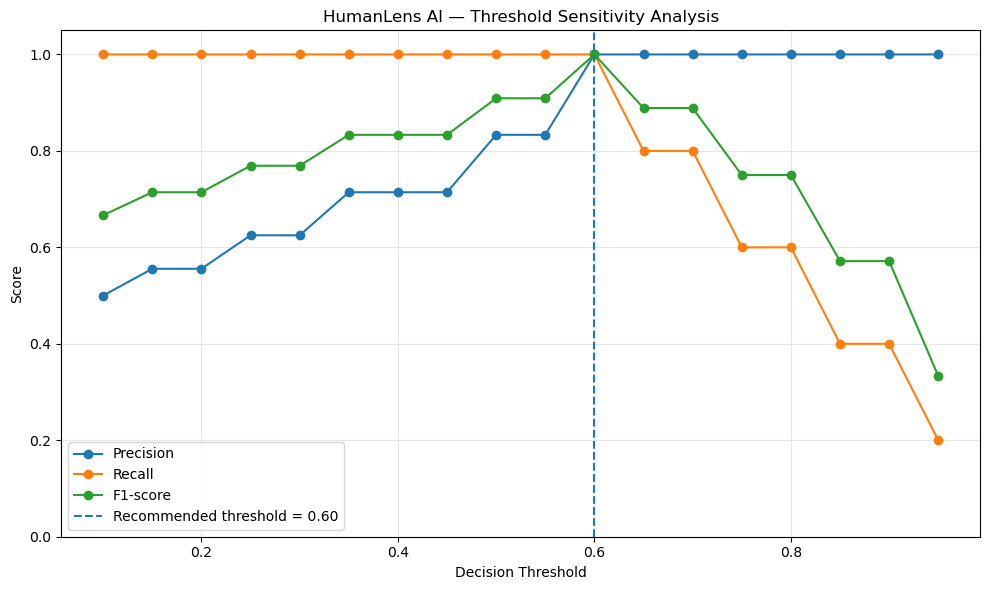

✅ Step 12 completed successfully.
Research-candidate threshold marked at 0.60


In [13]:
# ============================================================
# STEP 12 — Threshold Sensitivity Visualization
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1"],
    marker="o",
    label="F1-score"
)

# Mark the research-candidate threshold
plt.axvline(
    recommended_threshold,
    linestyle="--",
    label=f"Recommended threshold = {recommended_threshold:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("HumanLens AI — Threshold Sensitivity Analysis")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Step 12 completed successfully.")
print(
    f"Research-candidate threshold marked at "
    f"{recommended_threshold:.2f}"
)

In [16]:
# ============================================================
# STEP 13 — Threshold Decision Summary
# ============================================================

# Recalculate classification metrics for the recommended threshold
y_pred_recommended = (
    threshold_data["y_score"] >= recommended_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    threshold_data["y_true"],
    y_pred_recommended,
    labels=[0, 1]
).ravel()

precision = precision_score(
    threshold_data["y_true"],
    y_pred_recommended,
    zero_division=0
)

recall = recall_score(
    threshold_data["y_true"],
    y_pred_recommended,
    zero_division=0
)

f1 = f1_score(
    threshold_data["y_true"],
    y_pred_recommended,
    zero_division=0
)

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

threshold_summary = {
    "recommended_research_threshold": recommended_threshold,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "false_positive_rate": fpr,
    "false_negative_rate": fnr,
    "specificity": specificity,
    "sensitivity": recall,
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp,
    "dataset_type": "demonstration_threshold_data",
    "validation_status": "research_candidate_only"
}

print("HumanLens AI — Threshold Decision Summary")
print("=" * 60)

for key, value in threshold_summary.items():
    print(f"{key}: {value}")

print("\n⚠️ Important:")
print("These values come from the demonstration dataset.")
print("They must NOT be reported as validated production performance.")

print("\n✅ Step 13 completed successfully.")

HumanLens AI — Threshold Decision Summary
recommended_research_threshold: 0.6
precision: 1.0
recall: 1.0
f1_score: 1.0
false_positive_rate: 0.0
false_negative_rate: 0.0
specificity: 1.0
sensitivity: 1.0
true_negatives: 5
false_positives: 0
false_negatives: 0
true_positives: 5
dataset_type: demonstration_threshold_data
validation_status: research_candidate_only

⚠️ Important:
These values come from the demonstration dataset.
They must NOT be reported as validated production performance.

✅ Step 13 completed successfully.


In [18]:
# ============================================================
# STEP 14 — Save Threshold Summary as JSON
# ============================================================

import json

threshold_summary_path = RESULTS_DIR / "threshold_analysis_summary.json"

# Convert NumPy/Pandas values to native Python types
serializable_summary = {}

for key, value in threshold_summary.items():
    if isinstance(value, (np.integer,)):
        serializable_summary[key] = int(value)
    elif isinstance(value, (np.floating,)):
        serializable_summary[key] = float(value)
    elif isinstance(value, (np.bool_,)):
        serializable_summary[key] = bool(value)
    else:
        serializable_summary[key] = value

with open(threshold_summary_path, "w", encoding="utf-8") as f:
    json.dump(
        serializable_summary,
        f,
        indent=4
    )

print("Threshold summary saved successfully:")
print(threshold_summary_path)

print("\nSaved fields:")
for key in serializable_summary:
    print(f"  ✓ {key}")

print("\n✅ Step 14 completed successfully.")

Threshold summary saved successfully:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\threshold_analysis_summary.json

Saved fields:
  ✓ recommended_research_threshold
  ✓ precision
  ✓ recall
  ✓ f1_score
  ✓ false_positive_rate
  ✓ false_negative_rate
  ✓ specificity
  ✓ sensitivity
  ✓ true_negatives
  ✓ false_positives
  ✓ false_negatives
  ✓ true_positives
  ✓ dataset_type
  ✓ validation_status

✅ Step 14 completed successfully.


In [19]:
# ============================================================
# STEP 15 — Final Validation
# ============================================================

print("HumanLens AI — Notebook 12 Final Validation")
print("=" * 60)

# 1. Check required variables
required_variables = [
    "threshold_data",
    "threshold_results_df",
    "threshold_strategy_df",
    "recommended_threshold",
    "threshold_summary"
]

for variable in required_variables:
    assert variable in globals(), f"Missing variable: {variable}"

print("✓ Required variables are available")

# 2. Check threshold results
assert not threshold_results_df.empty
assert len(threshold_results_df) > 0

print("✓ Threshold results are available")

# 3. Check recommended threshold
assert 0 < recommended_threshold < 1

print(f"✓ Recommended research threshold: {recommended_threshold:.2f}")

# 4. Check metrics
for metric in ["precision", "recall", "f1_score"]:
    assert 0 <= threshold_summary[metric] <= 1

print("✓ Precision, Recall and F1 are valid")

# 5. Check confusion-matrix counts
assert all(
    isinstance(threshold_summary[key], (int, np.integer))
    for key in [
        "true_negatives",
        "false_positives",
        "false_negatives",
        "true_positives"
    ]
)

print("✓ Confusion-matrix counts are valid")

# 6. Check saved files
csv_path = RESULTS_DIR / "threshold_analysis_results.csv"
json_path = RESULTS_DIR / "threshold_analysis_summary.json"

assert csv_path.exists(), "Threshold CSV was not found"
assert json_path.exists(), "Threshold JSON was not found"

print("✓ CSV output exists")
print("✓ JSON output exists")

# 7. Read JSON back to verify it is valid
with open(json_path, "r", encoding="utf-8") as f:
    saved_summary = json.load(f)

assert saved_summary["validation_status"] == "research_candidate_only"

print("✓ JSON file successfully validated")
print("✓ Research-only validation status confirmed")

print("\n" + "=" * 60)
print("🎉 NOTEBOOK 12 VALIDATION COMPLETE")
print("=" * 60)

print("\nOutputs:")
print(f"  CSV  : {csv_path}")
print(f"  JSON : {json_path}")

print("\n⚠️ Research note:")
print("Threshold results currently use demonstration data.")
print("They must be replaced with real labeled evaluation data")
print("before reporting HumanLens model performance.")

HumanLens AI — Notebook 12 Final Validation
✓ Required variables are available
✓ Threshold results are available
✓ Recommended research threshold: 0.60
✓ Precision, Recall and F1 are valid
✓ Confusion-matrix counts are valid
✓ CSV output exists
✓ JSON output exists
✓ JSON file successfully validated
✓ Research-only validation status confirmed

🎉 NOTEBOOK 12 VALIDATION COMPLETE

Outputs:
  CSV  : E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\threshold_analysis_results.csv
  JSON : E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\threshold_analysis_summary.json

⚠️ Research note:
Threshold results currently use demonstration data.
They must be replaced with real labeled evaluation data
before reporting HumanLens model performance.
